# Задание 7. Применение сверточной нейронной сети для классификации изображений
В работе используется датасет CIFAR-100.
##### Индивидуальное задание:  
1. Суперкласс для классификации: 1 - рыбы.
2. Архитектура базовой модели нейронной сети:
- входной слой;
- слой двумерной свертки, 16 ядер 3*3 + relu;
- слой макс-пулинга 2*2;
- слой двумерной свертки, 32 ядра 3*3 + relu;
- слой макс-пулинга 2*2;
- слой преобразования в одномерный вектор;
- полносвязный слой, 32 нейрона, активация relu;
- полносвязный слой (выходной), число нейронов определить самостоятельно, активация softmax.  

In [2]:
# КОНСТАНТЫ
my_class = 1

## Порядок работы:  
### 1. Подключение библиотек

In [4]:
# Код приведен в качестве примера. Здесь может быть ваш код

import numpy as np # библиотека для работы с массивами
import pandas as pd # библиотека для численного анализа и работы с датафреймами

import matplotlib.pyplot as plt # библиотека для визуализации
import seaborn as sns # библиотека для более красивой визуализации

from sklearn.model_selection import train_test_split # метод для разбиения датасета
from sklearn.metrics import confusion_matrix # построение матрицы ошибок

import tensorflow as tf
from tensorflow.keras import utils # утилиты
from tensorflow.keras.models import Sequential # модель последовательной нейросети
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout # слои нейросети - могут потребоваться и другие

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau # это новый инструмент, см. ниже

# фиксируем последовательность генератора случайных чисел для поворяемости результатов
SEED = 42
from tensorflow.random import set_seed
from numpy.random import seed
seed(SEED)
set_seed(SEED)

In [5]:
# функция для работы с метаданными и метками классов
def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

### 2. Загрузка датасета

#### 2.1 Загружаем датасет CIFAR-100.  
Датасет уже разделен на обучающую и тестовую выборки.  
После загрузки датасета проверим размерность обучающей выборки и число уникальных меток классов.

In [8]:
# Код приведен в качестве примера. Здесь может быть ваш код

from tensorflow.keras.datasets import cifar100
(xf_train, yf_train), (xf_test, yf_test) = cifar100.load_data(label_mode='fine') # загружаем датасет с разметкой на классы
(xc_train, yc_train), (xc_test, yc_test) = cifar100.load_data(label_mode='coarse') # загружаем датасет с разметкой на суперклассы

print("Размерность обучающей выборки: ", xf_test.shape, "Размерность вектора меток классов: ", yf_test.shape)

num_classes = len(np.unique(yf_train))
num_superclasses = len(np.unique(yc_train))

print ("Число уникальных меток супер-классов: ", num_superclasses)
print ("Число уникальных меток классов: ", num_classes)

Размерность обучающей выборки:  (10000, 32, 32, 3) Размерность вектора меток классов:  (10000, 1)
Число уникальных меток супер-классов:  20
Число уникальных меток классов:  100


#### 2.2 Считываем текстовые метки классов и суперклассов

In [10]:
metadata_path = 'meta' # актуализировать путь к файлу с метаданными
metadata = unpickle(metadata_path)
superclass_dict = dict(list(enumerate(metadata[b'coarse_label_names'])))
print("Список названий суперклассов: \n", superclass_dict)

Список названий суперклассов: 
 {0: b'aquatic_mammals', 1: b'fish', 2: b'flowers', 3: b'food_containers', 4: b'fruit_and_vegetables', 5: b'household_electrical_devices', 6: b'household_furniture', 7: b'insects', 8: b'large_carnivores', 9: b'large_man-made_outdoor_things', 10: b'large_natural_outdoor_scenes', 11: b'large_omnivores_and_herbivores', 12: b'medium_mammals', 13: b'non-insect_invertebrates', 14: b'people', 15: b'reptiles', 16: b'small_mammals', 17: b'trees', 18: b'vehicles_1', 19: b'vehicles_2'}


In [11]:
classes = dict(list(enumerate(metadata[b'fine_label_names'])))
print("Список названий первых пяти классов:")
for i in range (5): print(classes[i])

Список названий первых пяти классов:
b'apple'
b'aquarium_fish'
b'baby'
b'bear'
b'beaver'


**Выполним проверочный вывод изображений из датасета:**

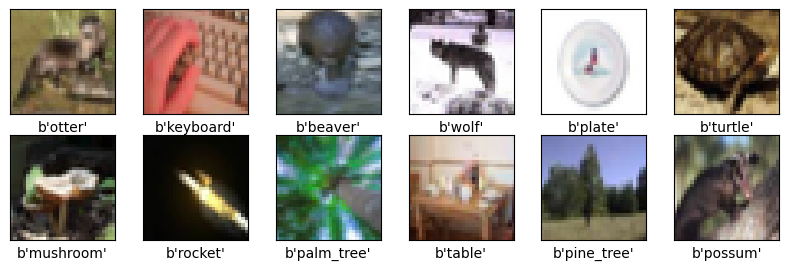

In [13]:
plt.figure(figsize=(10,3))
for i in range(100,112):
    plt.subplot(2,6,i-100+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(xf_train[i])
    plt.xlabel(classes[yf_train[i][0]])

### 3. Многоклассовая классификация изображений: подготовка данных для обучения и тестирования модели

#### 3.1. Выбираем из общей обучающей выборки суперкласс согласно варианту
В варианте задания указан номер суперкласса.  
Для дальнейшей работы его нужно выполнить следующие действия: 
1. Выделить из исходной обучающей и тестовой выборки и векторов меток элементы указанного суперкласса и его меток. (рекомендуется сохранить их в новых датафреймах). Выделение объектов указанного суперкласса рекомендуется оформить в виде функции, т.к. оно будет использоваться несколько раз.
2. Сохранить полученные данные в датафреймах соотвествующей размерности.

In [16]:
# Выделяем объекты класса из обучающей выборки

# Код приведен в качестве примера (но не примера для подражания :) ). Здесь может быть ваш код

x_train = np.empty(0,int)
y_train = np.empty(0,int)

#for i in (0,len(y_train)-1,1):
for i in range(0, len(yf_train)):
    if (yc_train[i] == my_class):
        x_train = np.append(x_train, (xf_train[i]))
        y_train = np.append(y_train, yf_train[i])   

y_train = np.reshape(y_train,(len(y_train), 1))
x_train = np.reshape(x_train, (len(y_train),32,32,3))
print ("Размерность датафрейма обучающей выборки: ", x_train.shape)
print ("Размерность датафрейма меток обучающей выборки: ", y_train.shape)

Размерность датафрейма обучающей выборки:  (2500, 32, 32, 3)
Размерность датафрейма меток обучающей выборки:  (2500, 1)


**При желании можно сделать проверочный вывод и убедиться, что обучающая выборка сформирована корректно**

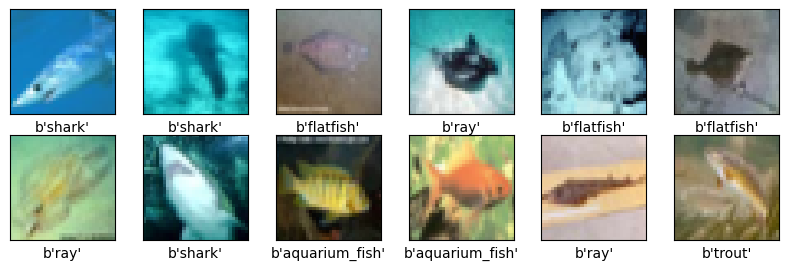

In [18]:
# проверочный вывод
plt.figure(figsize=(10,3))
for i in range(1,13):
    plt.subplot(2,6,i)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(classes[y_train[i][0]])

#### 3.2. Выбираем из общей тестовой выборки суперкласс согласно варианту
Выполняем те же действия с тестовой выборкой

In [20]:
# Выделяем объекты класса из тестовой выборки

# Код приведен в качестве примера (но не примера для подражания :) ). Здесь может быть ваш код

x_test = np.empty(0,int)
y_test = np.empty(0,int)

#for i in (0,len(y_train)-1,1):
for i in range(0, len(yf_test)):
    if (yc_test[i] == my_class):
        x_test = np.append(x_test, (xf_test[i]))
        y_test = np.append(y_test, yf_test[i])   

y_test = np.reshape(y_test,(len(y_test), 1))
x_test = np.reshape(x_test, (len(y_test),32,32,3))
print ("Размерность датафрейма тестовой выборки: ", x_test.shape)
print ("Размерность датафрейма меток тестовой выборки: ", y_test.shape)

Размерность датафрейма тестовой выборки:  (500, 32, 32, 3)
Размерность датафрейма меток тестовой выборки:  (500, 1)


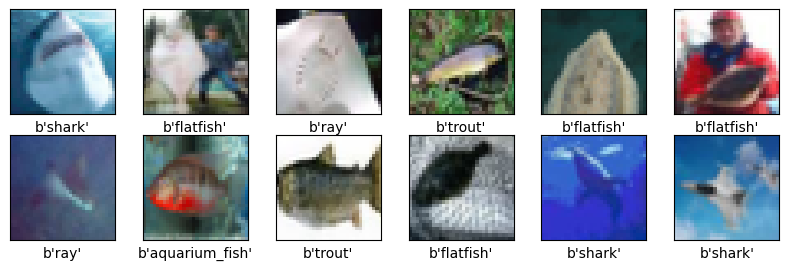

In [21]:
plt.figure(figsize=(10,3))
for i in range(1,13):
    plt.subplot(2,6,i)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_test[i])
    plt.xlabel(classes[y_test[i][0]])

#### 3.3. Нормализация данных и кодирование меток

Для окончательной подготовки данных необходимо:
1. выполнить нормализацию: цвет пикселя цветного изображения кодируется тремя целыми числами, значение которых лежит в интервале [0,255]. Рекомендуется привести их к интервалу [0,1].
2. Перекодировать метки классов: в суперклассе содержатся представители 5 классов, и их метки могут быть пронумерованы произвольно, а для обучения их нужно перенумеровать по порядку.
3. Выполнить преобразование меток класса в формат one hot encoding.

***Подсказка:*** можно использовать функцию `to_categorical` модуля `utils` библиотеки `tensorflow.keras`

In [25]:
# нормализуем исходные данные

# Здесь должен быть ваш код


In [26]:
# Перекодируем метки обучающей выборки

# Здесь должен быть ваш код


Исходные метки классов:  [ 1 32 67 73 91]
Номер класса:  1 Название класса: b'aquarium_fish'
Номер класса:  32 Название класса: b'flatfish'
Номер класса:  67 Название класса: b'ray'
Номер класса:  73 Название класса: b'shark'
Номер класса:  91 Название класса: b'trout'
Полученные метки классов:  [0 1 2 3 4]
Размерность датафрейма меток обучающей выборки:  (2500, 1)


In [27]:
# Перекодируем метки тестовой выборки


Размерность датафрейма меток тестовой выборки:  (500, 1)


In [28]:
# Кодируем метки one-hot

# Здесь должен быть ваш код

y_train[:5]

array([[1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 1., 0., 0.]])

### 4. Описание модели нейронной сети на базе класса Sequential 

Описание нейронной сети выполнить любым удобным способом.  
Архитектура сети должна соответствовать индивидуальному заданию.  
***Напоминание:***  
1. Слой входных сигналов нейронной сети должен соответствовать описанию примера обучающей выборки.  
2. Для многоклассовой классификации выходной слой содержит число нейронов, равное числу классов.  
3. Рекомендуемая функция активации выходного слоя - `softmax`.
4. Не забываем, что функция `softmax` возвращает не номер класса, а вероятность принадлежности объекта классу.  

In [31]:
# Для удобства проверки просьба вставить здесь описание нейросети из задания
# I→ C2D(16(3*3),relu)→ MP(2*2)→ C2D(16(3*3),relu)→ MP(2*2)→ F→ D(32,relu)→ D(out)

# Здесь должен быть ваш код


#### 4.3. Компиляция модели нейронной сети с соответствующими параметрами

Выполнить компиляцию модели с указанием актуальных параметров.  
Рекомендуется ознакомиться с документацией и примерами и разумно указать (как минимум) параметры loss, optimizer, metrics.  
Вывести описание (summary) модели и при желании - ее визуализацию.  
***Подсказка:*** для мультиклассовой классификации рекомендуется использовать функцию ошибки `categorical_crossentropy`

In [34]:
# Здесь должен быть ваш код


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 16)          │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 1152)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │          36,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             165 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 42,149 (164.64 KB)

 Trainable params: 42,149 (164.64 KB)

 Non-trainable params: 0 (0.00 B)

### 5. Обучение модели

Если вы уже обучали модели нейронных сетей, то у вас скорее всего уже возникало желание оптимизировать и автоматизировать некоторые моменты этого процесса.  
В Keras для этого используется механизм обратных вызовов - `Callbacks`.  
`Callbacks` в Keras — это объекты, которые позволяют настроить поведение модели во время обучения.  
Некоторые возможности Callbacks:  
- выполнение валидации в различных точках во время обучения;  
- установление контрольных точек модели через регулярные интервалы или когда она превышает определённый порог точности;   
- изменение скорости обучения модели, когда обучение перестаёт сходиться;   
- тонкая настройка верхних слоёв, когда обучение перестаёт сходиться;   
- и даже отправка электронных писем или сообщений, когда обучение заканчивается или когда превышен определённый порог производительности и т. д.   
 Более подробную информацию можно найти в [документации TensorFlow / Keras ](https://www.tensorflow.org/api_docs/python/tf/keras/callbacks).  
Пример описания `Callbacks` с настройками, близкими к настройкам "по умолчанию", приведен ниже.  

In [37]:
# Код приведен в качестве примера. Здесь может быть ваш код

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy', 
    factor=0.5,
    patience=5, 
    min_lr=0.000001,
    verbose=0)

save_best = ModelCheckpoint(
    filepath="base_weights.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="auto",
    verbose=1)

early_stop = EarlyStopping(
    monitor="val_accuracy",
    min_delta=0.0001,
    patience=5,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=True,
    start_from_epoch=0
)

Ниже приведен пример обучения модели с использованием `Callbacks`.  

In [39]:
# Код приведен в качестве примера. Здесь может быть ваш код

# Обучаем модель
history = baseline_model.fit(x_train, y_train,
              batch_size=32,
              epochs=25,
              validation_data=(x_test, y_test),
              callbacks=[save_best, reduce_lr, early_stop],
              verbose=1)

Epoch 1/25
71/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3178 - loss: 1.5082
Epoch 1: val_accuracy improved from -inf to 0.48600, saving model to base_weights.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.3261 - loss: 1.4947 - val_accuracy: 0.4860 - val_loss: 1.2086 - learning_rate: 0.0010
Epoch 2/25
71/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5210 - loss: 1.1811
Epoch 2: val_accuracy improved from 0.48600 to 0.53800, saving model to base_weights.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5224 - loss: 1.1777 - val_accuracy: 0.5380 - val_loss: 1.0901 - learning_rate: 0.0010
Epoch 3/25
75/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5763 - loss: 1.0742
Epoch 3: val_accuracy improved from 0.53800 to 0.59600, saving model to base_weights.keras
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5774 - loss: 1.0727 - val_accuracy: 0.5960 - val_loss: 1.0134 - learning_rate: 0.0010
Epoch 4/25
73/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy:

Вывести графики, демонстрирующие динамику процесса обучения.

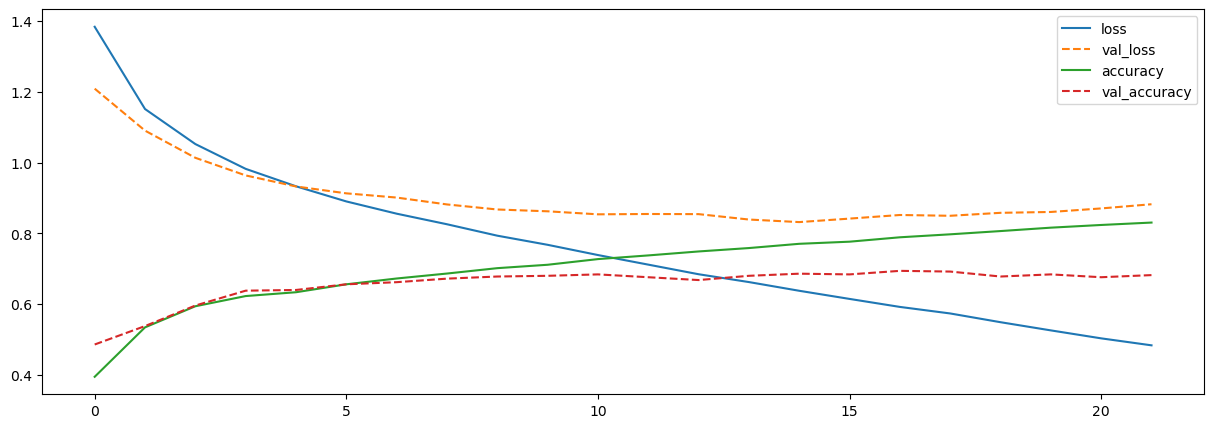

In [41]:
# Здесь должен быть ваш код


### 6. Оценка качества работы многоклассового классификатора  

#### 6.1 Определить долю правильных ответов на обучающей и тестовой выборке

In [44]:
# Здесь должен быть ваш код


Доля правильных ответов на обучающей выборке: 0.7803999781608582
Доля правильных ответов на тестовой выборке: 0.6940000057220459


#### 6.2. Построить матрицу ошибок

In [46]:
# Здесь должен быть ваш код


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Confusion matrix 
 [[86  5  2  5  2]
 [ 5 65 10  2 18]
 [ 1  6 51 33  9]
 [ 3  9 11 67 10]
 [ 3  7  8  4 78]]

 Размер тестовой выборки:  500 
 Из них распознано верно:  347 
 Доля правильных ответов - Accuracy:  0.694


### 7. Оптимизация нейронной сети

Используя знания, полученные при изучении основного и дополнительного материала, внести в исходную `baseline` модель изменения таким образом, чтобы повысить качество работы.  
**Целевое значение accuracy не менее 0,7**  
В отчете сохранить результаты всех проведенных экспериментов с выводами и обосновать выбор лучшего результата.  
Требуется продемонстрировать не менее 3 вариантов модификаций `baseline` модели. Попытаться обосновать ваши действия. 

In [49]:
# При необходимости импортируем нужные модули

# Здесь может быть ваш код


Описываем на основе `baseline` оптимизированную модель, обучаем, тестируем полученный результат, делаем вывод.

In [51]:
# Вносим изменения в baseline-модель 

# Здесь должен быть ваш код

# Компилируем оптимизированную модель 

# Здесь должен быть ваш код

# Выводим описание оптимизированной модели 
# Здесь должен быть ваш код


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 30, 30, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 15, 15, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 15, 15, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 13, 13, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 6, 6, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │         294,976 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 379,589 (1.45 MB)

 Trainable params: 379,589 (1.45 MB)

 Non-trainable params: 0 (0.00 B)

None


**Подсказка:** Для повышения качества обученной модели можно экспериментировать не только с параметрами самой модели, но и с параметрами процесса обучения за счет настройки Callbacks.

In [53]:
# Настраиваем Callbacks

# Здесь может быть ваш код


Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2414 - loss: 1.5826
Epoch 1: val_accuracy improved from -inf to 0.40400, saving model to best_weights.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.2424 - loss: 1.5811 - val_accuracy: 0.4040 - val_loss: 1.3845 - learning_rate: 0.0010
Epoch 2/100
39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3893 - loss: 1.3674
Epoch 2: val_accuracy did not improve from 0.40400
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3898 - loss: 1.3665 - val_accuracy: 0.3840 - val_loss: 1.2977 - learning_rate: 0.0010
Epoch 3/100
39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.4379 - loss: 1.2885
Epoch 3: val_accuracy improved from 0.40400 to 0.48200, saving model to best_weights.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.4378 - loss: 1.2883 - val_accuracy: 0.4820 - val_loss: 1.2544 - learning_rate: 0.0010
Epoch 4/100
39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.4437 - loss: 1.2640
Epoch 

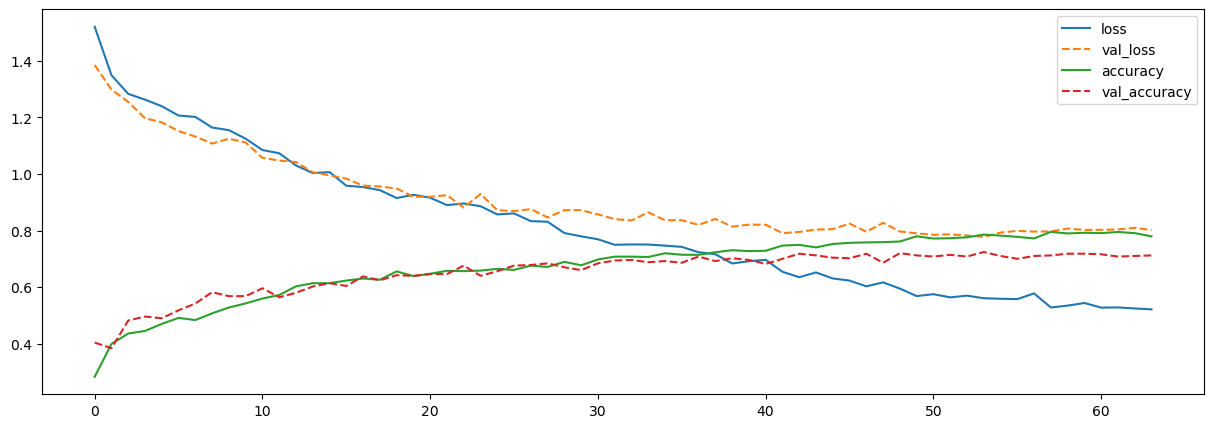

In [54]:
# Обучаем модель
# Здесь должен быть ваш код

# Визуализируем динамику процесса обучения
# Здесь должен быть ваш код


In [55]:
# Определяем accuracy для обучающей и тестовой выборок
# Здесь должен быть ваш код

# Строим матрицу ошибок, определяем метрику качества
# Здесь должен быть ваш код



Доля правильных ответов на обучающей выборке: 0.8848000168800354
Доля правильных ответов на тестовой выборке: 0.7239999771118164
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Confusion matrix 
 [[84  6  1  4  5]
 [ 3 78 11  4  4]
 [ 3  6 66 20  5]
 [ 3  6 21 62  8]
 [ 3  9  8  8 72]]

 Размер тестовой выборки:  500 
 Из них распознано верно:  362 
 Доля правильных ответов - Accuracy:  0.724


## 8. Сохранение оптимизированной модели в файл

In [57]:
# Здесь должен быть ваш код


## ВЫВОДЫ ПО ПРОДЕЛАННОЙ РАБОТЕ

**ЗДЕСЬ ДОЛЖЕН БЫТЬ ВАШ ТЕКСТ**